# ¿Quién gestiona mejor sus finanzas públicas?
## Un vistazo a 30 años de datos fiscales del FMI (1995–2024)

Este análisis tiene la finalidad de responder una pregunta simple que surge al seguir las noticias sobre deuda y ajustes fiscales en distintos países: ¿hay patrones reales detrás de aquellos países que "gestionan bien" sus finanzas públicas, o es solo narrativa política?

El FMI publica un histórico enorme y gratuito de indicadores fiscales para más de 190 países, por lo que se utiliza como fuente principal de datos.

**Fuente principal:** IMF World Economic Outlook + Fiscal Monitor,
vía la [IMF DataMapper API](https://www.imf.org/external/datamapper)

---

> **Pregunta central:** En un contexto de tensión financiera global,
> ¿qué países gestionan mejor sus finanzas públicas y qué patrones
> explican esa buena gestión?

## 1. Librerías

Todas las librerías utilizadas forman parte de una instalación
estándar de Python/Anaconda. No se requiere ninguna instalación
adicional excepto `openpyxl`, necesaria para leer archivos Excel
del Banco Mundial.

In [1]:
import requests  # peticiones HTTP a la API del FMI
import pandas as pd  # manipulación de datos
import numpy as np  # operaciones matemáticas
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import json

from src.utils import (
    IMF_BASE_URL,
    get_imf_indicator,
    normalize_robust,
    classify_solvency_dynamics,
)

## 2. Descarga de Datos

### 2.1 Fuente: FMI DataMapper API

El Fondo Monetario Internacional (FMI) publica datos fiscales y
macroeconómicos de 190+ países a través de su API pública y gratuita.
No requiere registro ni API key.

- **URL base:** `https://www.imf.org/external/datamapper/api/v1/`
- **Licencia:** IMF Open Data — libre reutilización con atribución
- **Cobertura:** 190–229 países según indicador
- **Periodo disponible:** 1980–2031 (histórico + proyecciones)

### 2.2 Indicadores seleccionados

| Código FMI | Variable | Descripción | Cobertura |
|-----------|---------|-------------|-----------|
| `GGXWDG_NGDP` | `debt_pct_gdp` | Deuda bruta gobierno % PIB | ~226 países |
| `GGXCNL_NGDP` | `deficit_pct_gdp` | Déficit/superávit % PIB | ~229 países |
| `NGDP_RPCH` | `gdp_growth_pct` | Crecimiento PIB real % | ~229 países |
| `LUR` | `unemployment_rate` | Tasa de desempleo % | ~122 países |

### 2.3 Función de descarga

Creamos una función reutilizable `get_imf_indicator()` que encapsula
la llamada a la API y devuelve un DataFrame limpio. Así evitamos
repetir el mismo código para cada indicador y el proceso es
fácilmente reproducible si se quieren añadir nuevos indicadores
en el futuro.

In [2]:
# Concretamos los indicadores que queremos descargar
IMF_INDICATORS = {
    "GGXWDG_NGDP": "debt_pct_gdp",  # deuda bruta % PIB
    "GGXCNL_NGDP": "deficit_pct_gdp",  # déficit/superávit % PIB
    "NGDP_RPCH": "gdp_growth_pct",  # crecimiento PIB real %
    "LUR": "unemployment_rate",  # tasa de desempleo %
}

# Vamos por la descarga de datos en una lista vacía

dfs = []

for codigo, col_name in IMF_INDICATORS.items():
    print(f"{col_name}({codigo})...", end="")
    df_ind = get_imf_indicator(codigo, col_name)
    if df_ind is not None:
        dfs.append(df_ind)
        print(
            f"{len(df_ind):,} filas | {df_ind['geo'].nunique()}) países"
            f"| {df_ind['year'].min()}-{df_ind['year'].max()}"
        )

debt_pct_gdp(GGXWDG_NGDP)...8,113 filas | 226) países| 1980-2031
deficit_pct_gdp(GGXCNL_NGDP)...8,848 filas | 229) países| 1980-2031
gdp_growth_pct(NGDP_RPCH)...10,914 filas | 229) países| 1980-2031
unemployment_rate(LUR)...5,165 filas | 122) países| 1980-2031


In [3]:
# Merge con todos los indicadores

# outer join: mantiene todos los países aunque algún indicador falte
df_raw = dfs[0]
for df_ind in dfs[1:]:
    df_raw = pd.merge(df_raw, df_ind, on=["geo", "year"], how="outer")

print(f"Dataset crudo: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
display(df_raw.head(5))
display(df_raw.tail(5))

Dataset crudo: 10,964 filas x 6 columnas


,geo,year,debt_pct_gdp,deficit_pct_gdp,gdp_growth_pct,unemployment_rate
0,ABW,1986,NaN,NaN,NaN,19.6
1,ABW,1987,NaN,NaN,16.1,14.5
2,ABW,1988,NaN,NaN,18.6,5.0
3,ABW,1989,NaN,NaN,12.1,1.5
4,ABW,1990,NaN,NaN,4.0,1.3


,geo,year,debt_pct_gdp,deficit_pct_gdp,gdp_growth_pct,unemployment_rate
10959,ZWE,2027,41.4,-0.9,4.2,NaN
10960,ZWE,2028,40.4,-0.9,4.2,NaN
10961,ZWE,2029,39.5,-0.9,4.2,NaN
10962,ZWE,2030,38.5,-0.9,4.2,NaN
10963,ZWE,2031,37.6,-0.9,4.2,NaN


## 3. Limpieza y Preparación

### 3.1 Filtrar periodo histórico

El FMI incluye proyecciones hasta 2031 mezcladas con los datos
históricos. Las excluimos porque son estimaciones, no observaciones
reales. Trabajamos con el periodo **1995–2024** porque:

- Antes de 1995 muchos países en desarrollo tienen series muy incompletas
- 2025 en adelante son proyecciones del FMI, no datos observados

In [4]:
# El FMI incluye proyecciones hasta 2031.
# Las excluimos porque son estimaciones, no datos observados.
# Empezamos en 1995: antes hay muchos países con series incompletas.

YEAR_START = 1995
YEAR_END = 2024

df = df_raw[(df_raw["year"] >= YEAR_START) & (df_raw["year"] <= YEAR_END)].copy()

In [5]:
print(f"Periodo: {YEAR_START}–{YEAR_END} | Filas: {len(df):,}")

Periodo: 1995–2024 | Filas: 6,711


### 3.2 Filtrar países con cobertura suficiente

Muchos países tienen series temporales muy incompletas — reportan
datos solo para algunos años. Mantenemos únicamente los países
que tienen dato en al menos el **70% de los años** del periodo
para el indicador principal (`debt_pct_gdp`).

Este criterio garantiza que los análisis temporales son
representativos y no están distorsionados por países con
una o dos observaciones aisladas.

In [6]:
total_years = YEAR_END - YEAR_START + 1

cobertura = df.groupby("geo")["debt_pct_gdp"].apply(
    lambda x: x.notna().sum() / total_years
)

paises_ok = cobertura[cobertura >= 0.70].index.tolist()

df = df[df["geo"].isin(paises_ok)].copy()

print(f"Países con cobertura ≥70%: {len(paises_ok)}")

print(f"Filas restantes: {len(df):,}")

Países con cobertura ≥70%: 214
Filas restantes: 6,363


### 3.3 Añadir nombres de países y eliminar agregados regionales

El FMI usa códigos ISO de 3 letras para identificar países, pero
también incluye **agregados regionales** con sus propios códigos
(WEOWORLD = mundo entero, EURO = eurozona, EU = Unión Europea...).
Estos agregados no son países reales — son promedios ponderados
que el FMI publica internamente.

Los identificamos porque no tienen entrada en el endpoint
`/countries` del FMI (que solo lista países reales), y los
eliminamos para que no distorsionen el análisis.

In [7]:
url_countries = f"{IMF_BASE_URL}/countries"
countries_raw = requests.get(url_countries, timeout=30).json().get("countries", {})

# Diccionario {código_iso3: nombre_completo}
nombre_pais = {code: info["label"] for code, info in countries_raw.items()}
df["country_name"] = df["geo"].map(nombre_pais).fillna(df["geo"])

print(f"NaN restantes: {df['country_name'].isna().sum()}")

NaN restantes: 0


In [8]:
print("Muestra de country_name:")
display(df[["geo", "country_name"]].drop_duplicates().head(20))

# Cuántos países tienen nombre real vs código repetido
# Si country_name == geo significa que no encontró el nombre
sin_nombre = df[df["country_name"] == df["geo"]]["geo"].unique()
print(f"\nPaíses SIN nombre real (solo tienen el código): {len(sin_nombre)}")
print(sorted(sin_nombre))

Muestra de country_name:


,geo,country_name
9,ABW,Aruba
61,ADVEC,ADVEC
98,AFG,Afghanistan
126,AFQ,AFQ
178,AGO,Angola
230,ALB,Albania
267,AND,Andorra
313,APQ,APQ
365,ARE,United Arab Emirates
417,ARG,Argentina



Países SIN nombre real (solo tienen el código): 32
['ADVEC', 'AFQ', 'APQ', 'AS5', 'AZQ', 'CAQ', 'CBQ', 'CMQ', 'DA', 'EAQ', 'EDE', 'EEQ', 'EU', 'EUQ', 'EURO', 'MAE', 'MECA', 'MEQ', 'NAQ', 'NMQ', 'OAE', 'OEMDC', 'PIQ', 'SAQ', 'SEQ', 'SMQ', 'SSA', 'SSQ', 'WE', 'WEOWORLD', 'WEQ', 'WHQ']


In [9]:
# Identificamos los agregados: son los que no encontraron nombre
agregados = df[df["country_name"] == df["geo"]]["geo"].unique()

# Guardamos la cantidad de filas antes de guardar el nuevo df:
filas_antes = len(df)

# Los eliminamos del dataset
df = df[~df["geo"].isin(agregados)].copy()
# ~ es el operador NOT en pandas
# isin() devuelve True si el valor está en la lista
# ~isin() devuelve True si NO está → nos quedamos con los países reales

print(f"Agregados eliminados: {len(agregados)}")
print(f"   {sorted(agregados)}")
print(f"\n   Filas antes: {filas_antes: ,}")
print(f"   Filas después: {len(df):,}")
print(f"   Países reales: {df['geo'].nunique()}")

# Verificamos que ya no quedan agregados
sin_nombre = df[df["country_name"] == df["geo"]]["geo"].unique()
print(f"Países sin nombre real restantes: {len(sin_nombre)}")

Agregados eliminados: 32
   ['ADVEC', 'AFQ', 'APQ', 'AS5', 'AZQ', 'CAQ', 'CBQ', 'CMQ', 'DA', 'EAQ', 'EDE', 'EEQ', 'EU', 'EUQ', 'EURO', 'MAE', 'MECA', 'MEQ', 'NAQ', 'NMQ', 'OAE', 'OEMDC', 'PIQ', 'SAQ', 'SEQ', 'SMQ', 'SSA', 'SSQ', 'WE', 'WEOWORLD', 'WEQ', 'WHQ']

   Filas antes:  6,363
   Filas después: 5,403
   Países reales: 182
Países sin nombre real restantes: 0


### 3.4 Clasificación de países por región y nivel de renta

Añadimos dos variables categóricas que enriquecerán el análisis:

- `region_wb` → permite comparar grupos geográficos:
  *"¿gestiona mejor la deuda Europa que América Latina?"*

- `income_group` → permite comparar por nivel de desarrollo:
  *"¿los países ricos gestionan mejor sus finanzas que los emergentes?"*

**¿Por qué el Banco Mundial y no el FMI?**
La clasificación más natural sería usar los grupos del FMI. Sin
embargo, el endpoint `/groups` estaba en mantenimiento (error 503)
durante el desarrollo de este proyecto. El Banco Mundial publica
anualmente el archivo `CLASS.xlsx` con clasificación oficial de
todos los países — fuente igualmente rigurosa y de libre acceso.

**Nota técnica:** el archivo se descarga con `verify=False` porque
el certificado SSL del servidor del Banco Mundial está caducado.
Esto es aceptable para fuentes públicas de confianza.

**Tres países requirieron clasificación manual:**

| País | Motivo | Región | Renta |
|------|--------|--------|-------|
| TWN (Taiwán) | No reconocido por la ONU | East Asia & Pacific | High income |
| WBG (West Bank & Gaza) | Territorio bajo administración especial | Middle East & North Africa | Lower middle income |
| VEN (Venezuela) | Retirada del Banco Mundial en 2019 por falta de datos fiables | Latin America & Caribbean | Upper middle income |


In [10]:
# ── CLASIFICACIÓN OFICIAL — BANCO MUNDIAL 2024 ───────────────────────────────
#
# El Banco Mundial publica anualmente el archivo CLASS.xlsx con la
# clasificación oficial de todos los países por:
#   - income_group: nivel de renta (High / Upper middle / Lower middle / Low)
#   - region_wb:    región geográfica según criterio del Banco Mundial
#
# Descargamos directamente con verify=False porque el certificado
# SSL de su servidor está caducado.
# NOTA: verify=False solo es aceptable para fuentes públicas de confianza.
#
# Inspeccionando el archivo crudo confirmamos que:
#   - Fila 0: cabeceras (Economy, Code, Region, Income group...)
#   - Fila 1 en adelante: datos reales → header=0

import io

url_wb = "https://databank.worldbank.org/data/download/site-content/CLASS.xlsx"
response = requests.get(url_wb, verify=False, timeout=30)

wb_class = pd.read_excel(
    io.BytesIO(response.content),
    sheet_name="List of economies",
    header=0,  # cabeceras en fila 0, datos desde fila 1
)

# Renombramos por posición — sabemos el orden por inspección previa
wb_class.columns = [
    "country_name_wb",
    "geo",
    "region_wb",
    "income_group",
    "lending",
    "extra",
]

# Solo las columnas útiles
wb_class = wb_class[["geo", "region_wb", "income_group"]].copy()

# Eliminamos filas vacías y filas que no son países reales
# (notas al pie y subtítulos del Excel tienen códigos != 3 letras)
wb_class = wb_class.dropna(subset=["geo", "income_group"])
wb_class = wb_class[wb_class["geo"].str.len() == 3]

# ── MERGE CON NUESTRO DATASET ─────────────────────────────────────────────────
#
# how='left' → mantenemos todos los países de df
# aunque no estén en wb_class (quedarían NaN)

df = pd.merge(df, wb_class, on="geo", how="left")

# TWN y WBG no están en el Banco Mundial por razones políticas
# los clasificamos manualmente con el criterio geográfico más lógico
manual = {
    "TWN": ("East Asia & Pacific", "High income"),
    "WBG": ("Middle East & North Africa", "Lower middle income"),
    "VEN": ("Latin America & Caribbean", "Upper middle income"),
}
for geo, (region, income) in manual.items():
    df.loc[df["geo"] == geo, "region_wb"] = region
    df.loc[df["geo"] == geo, "income_group"] = income

# ── VERIFICACIÓN FINAL ────────────────────────────────────────────────────────
sin_clasificar = df[df["income_group"].isna()]["geo"].unique()

print(f"   Dataset final: {df.shape}")
print(f"   Países: {df['geo'].nunique()}")
print(f"   Sin clasificar: {len(sin_clasificar)}")

print(f"\nPaíses por nivel de renta:")
print(
    df.groupby("income_group")["geo"].nunique().sort_values(ascending=False).to_string()
)

print(f"\nPaíses por región (Banco Mundial):")
print(df.groupby("region_wb")["geo"].nunique().sort_values(ascending=False).to_string())

c:\Users\User\Desktop\Ordena antiguo\Data Science\Portfolio\data-projects\data-projects\Análisis fiscal global\.venv\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'databank.worldbank.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\User\Desktop\Ordena antiguo\Data Science\Portfolio\data-projects\data-projects\Análisis fiscal global\.venv\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'databankfiles.worldbank.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


   Dataset final: (5403, 9)
   Países: 182
   Sin clasificar: 0

Países por nivel de renta:
income_group
High income            60
Lower middle income    51
Upper middle income    50
Low income             21

Países por región (Banco Mundial):
region_wb
Europe & Central Asia         50
Sub-Saharan Africa            43
Latin America & Caribbean     33
East Asia & Pacific           29
Middle East & North Africa    17
South Asia                     8
North America                  2


In [11]:
# ── ESTADO ACTUAL DEL DATASET ─────────────────────────────────────────────────
print(f"Shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")
print(f"\nValores perdidos:")
print(df.isnull().sum().to_string())

Shape: (5403, 9)
Columnas: ['geo', 'year', 'debt_pct_gdp', 'deficit_pct_gdp', 'gdp_growth_pct', 'unemployment_rate', 'country_name', 'region_wb', 'income_group']

Valores perdidos:
geo                     0
year                    0
debt_pct_gdp          324
deficit_pct_gdp       207
gdp_growth_pct         16
unemployment_rate    2220
country_name            0
region_wb               0
income_group            0


### 3.5 Detección y documentación de valores extremos

Antes de crear métricas derivadas, inspeccionamos los valores
extremos del dataset para distinguir entre **errores de datos**
(que habría que corregir) y **casos reales con contexto histórico**
(que hay que documentar pero mantener).

In [12]:
# ── IDENTIFICAR OUTLIERS EXTREMOS ─────────────────────────────────────────────
#
# Antes de continuar, identificamos qué países tienen valores extremos
# para documentarlos y decidir si son datos reales o errores

display(df.describe())

print("País con mayor deuda (>200% PIB):")
print(
    df[df["debt_pct_gdp"] > 300][["geo", "country_name", "year", "debt_pct_gdp"]]
    .sort_values("debt_pct_gdp", ascending=False)
    .head(5)
    .to_string()
)

print("\nPaís con déficit más extremo (<-50% PIB):")
print(
    df[df["deficit_pct_gdp"] < -50][["geo", "country_name", "year", "deficit_pct_gdp"]]
    .sort_values("deficit_pct_gdp")
    .head(5)
    .to_string()
)

,year,debt_pct_gdp,deficit_pct_gdp,gdp_growth_pct,unemployment_rate
count,5403.000000,5079.000000,5196.000000,5387.000000,3183.000000
mean,2009.630020,54.227702,-2.023364,3.627696,8.909708
std,8.606407,41.984568,6.395980,5.870739,6.065390
min,1995.000000,0.000000,-123.400000,-54.400000,0.700000
25%,2002.000000,28.650000,-4.500000,1.500000,4.900000
50%,2010.000000,45.800000,-2.300000,3.700000,7.300000
75%,2017.000000,69.150000,0.000000,5.900000,10.900000
max,2024.000000,600.100000,125.100000,148.000000,70.000000


País con mayor deuda (>200% PIB):
      geo country_name  year  debt_pct_gdp
2864  LBR      Liberia  2003         600.1
2865  LBR      Liberia  2004         543.4
2866  LBR      Liberia  2005         488.5
2861  LBR      Liberia  2000         468.1
2862  LBR      Liberia  2001         465.2

País con déficit más extremo (<-50% PIB):
      geo       country_name  year  deficit_pct_gdp
1937  GNQ  Equatorial Guinea  1995           -123.4
4824  TLS        Timor-Leste  2016            -55.7


Se identificaron tres casos extremos, todos ellos datos reales:

| País | Indicador | Valor | Contexto |
|------|-----------|-------|---------|
| LBR (Liberia) | `debt_pct_gdp` | 600% (2003) | Deuda acumulada durante guerra civil 1989–2003. Condonada bajo iniciativa HIPC del FMI en 2010 |
| GNQ (Guinea Ecuatorial) | `deficit_pct_gdp` | -123% (1995) | PIB muy pequeño antes del boom petrolero. Cualquier gasto se dispara en términos relativos |
| TLS (Timor-Leste) | `deficit_pct_gdp` | -55% (2016) | Dependencia total del fondo petrolero. Caída del precio del crudo en 2015–2016 |

Se decide mantener los datos extremos en el dataset. Se tendrán en cuenta para la creación de nuevas métricas.

### 3.6 Métricas derivadas

Creamos tres indicadores propios que no existen en ningún dataset
original. Esto añade valor analítico al proyecto y permite
responder preguntas que los indicadores crudos no pueden responder
directamente.

| Métrica | Tipo | Para qué pregunta |
|---------|------|------------------|
| `debt_category` | Categórica ordinal | Q1 — clasificar nivel de deuda |
| `fiscal_dynamics` | Categórica nominal | Q2 y Q3 — perfil fiscal combinado |
| `fiscal_health_score` | Numérica continua 0–100 | Q5 — ranking de gestión fiscal |

**Sobre el `fiscal_health_score`:**
Se construye con normalización por umbrales fijos (no Min-Max simple)
porque los umbrales tienen significado económico real. Un país con
deuda del 0% no obtiene 100 puntos "porque es el mejor del grupo"
sino porque 0% es objetivamente la mejor situación posible.

In [13]:
# ────────────────────────────── debt_category ─────────────────────────
# Categoría de deuda según criterio de Maastricht
# El Tratado de Maastricht fijó el 60% como límite "sostenible" para la UE.
# Usamos ese umbral como referencia global.
df["debt_category"] = pd.cut(
    df["debt_pct_gdp"],
    bins=[0, 60, 90, 120, 9999],
    labels=[
        "Bajo control (<60%)",
        "Moderada (60–90%)",
        "Preocupante (90–120%)",
        "Nivel Crítico (>120%)",
    ],
)

print(f"debt_category:   {df['debt_category'].notna().sum():,} valores")

debt_category:   5,027 valores


In [14]:
# ────────────────────────────── fiscal_position ─────────────────────────
# Posición fiscal combinada
# Combina deuda y déficit para clasificar la situación fiscal de cada país-año

df["fiscal_dynamics"] = df.apply(classify_solvency_dynamics, axis=1)

print(f"   fiscal_dynamics: {df['fiscal_dynamics'].notna().sum():,} valores")

   fiscal_dynamics: 5,186 valores


In [15]:
# ── FISCAL HEALTH SCORE ───────────────────────────────────────────────────────
#
# Índice propio de salud fiscal (0–100) que combina 3 indicadores.
# Cuanto más alto, mejor gestión fiscal.
#
# Construcción:
# 1. Normalizamos cada indicador entre 0 y 100 con Min-Max scaling:
#    valor_norm = (valor - min) / (max - min) * 100
#
# 2. La deuda la INVERTIMOS porque menos deuda = mejor salud:
#    deuda_norm = 100 - ((deuda - min) / (max - min) * 100)
#
# 3. Combinamos con pesos iguales (1/3 cada uno):
#    score = (deuda_norm + deficit_norm + crecimiento_norm) / 3
#
# Trabajamos solo con filas que tengan los 3 indicadores disponibles

# Normalización con umbrales fijos (Lógica de negocio)
debt_norm = 100 - normalize_robust(df["debt_pct_gdp"], 0, 150)  # 150% ya es "techo"
deficit_norm = normalize_robust(df["deficit_pct_gdp"], -10, 5)  # De -10% a +5%
growth_norm = normalize_robust(df["gdp_growth_pct"], -2, 8)  # De -2% a +8%

df["fiscal_health_score"] = ((debt_norm + deficit_norm + growth_norm) / 3).round(2)
print(f"   fiscal_health_score: {df['fiscal_health_score'].notna().sum():,} valores")

   fiscal_health_score: 5,031 valores


## 4. Segmentación del Dataset

El indicador de desempleo solo está disponible para 108 de los
182 países. En vez de eliminar países o eliminar el indicador,
creamos dos versiones del dataset con propósitos distintos:

| Dataset | Países | Columnas | Uso |
|---------|--------|----------|-----|
| `df_full` | 182 | 11 | Análisis global — máxima cobertura geográfica |
| `df_unemp` | 108 | 14 | Análisis con desempleo y vulnerabilidad estructural |

**Criterio de inclusión en `df_unemp`:** países con datos de
desempleo en al menos el 70% de los años del periodo 1995–2024.

In [16]:
# ── PASO 6: SEGMENTACIÓN ESTRATÉGICA DEL DATASET ──────────────────────────────

cobertura_unemp = df.groupby("geo")["unemployment_rate"].apply(
    lambda x: x.notna().mean()
)
paises_unemp = cobertura_unemp[cobertura_unemp >= 0.50].index.tolist()

# df completo pero sin datos de desempleo
df_full = df.drop(columns=["unemployment_rate"]).drop_duplicates().copy()

# df con datos de desempelo
df_unemp = df[df["geo"].isin(paises_unemp)].dropna(subset=["unemployment_rate"]).copy()
print(f"df_full:  {df_full['geo'].nunique()} países (Cobertura total)")
print(f"df_unemp: {df_unemp['geo'].nunique()} países (Con historial de desempleo)")

df_full:  182 países (Cobertura total)
df_unemp: 108 países (Con historial de desempleo)


In [17]:
print("df_full:")
print(f"   Shape:   {df_full.shape}")
print(f"   Columnas: {df_full.columns.tolist()}")
print(f"   NaN:\n{df_full.isnull().sum().to_string()}")

print("\ndf_unemp:")
print(f"   Shape:   {df_unemp.shape}")
print(f"   Columnas: {df_unemp.columns.tolist()}")
print(f"   NaN:\n{df_unemp.isnull().sum().to_string()}")

df_full:
   Shape:   (5403, 11)
   Columnas: ['geo', 'year', 'debt_pct_gdp', 'deficit_pct_gdp', 'gdp_growth_pct', 'country_name', 'region_wb', 'income_group', 'debt_category', 'fiscal_dynamics', 'fiscal_health_score']
   NaN:
geo                      0
year                     0
debt_pct_gdp           324
deficit_pct_gdp        207
gdp_growth_pct          16
country_name             0
region_wb                0
income_group             0
debt_category          376
fiscal_dynamics        217
fiscal_health_score    372

df_unemp:
   Shape:   (3132, 12)
   Columnas: ['geo', 'year', 'debt_pct_gdp', 'deficit_pct_gdp', 'gdp_growth_pct', 'unemployment_rate', 'country_name', 'region_wb', 'income_group', 'debt_category', 'fiscal_dynamics', 'fiscal_health_score']
   NaN:
geo                      0
year                     0
debt_pct_gdp           161
deficit_pct_gdp        118
gdp_growth_pct           9
unemployment_rate        0
country_name             0
region_wb                0
income_group

### 4.1 Vulnerability Score (solo `df_unemp`)

El `fiscal_health_score` mide qué tan bien gestiona un país sus
finanzas. El `vulnerability_score` mide algo distinto y complementario:
**cuántos factores de riesgo simultáneos** tiene ese país ese año;
un país puede tener un score fiscal medio pero estar en zona de
riesgo si coinciden varios factores adversos al mismo tiempo.

La métrica suma condiciones booleanas (True=1, False=0):

| Factor | Umbral | Criterio |
|--------|--------|---------|
| Deuda alta | > 90% PIB | FMI Fiscal Monitor — zona de vigilancia |
| Déficit excesivo | < -3% PIB | Pacto de Estabilidad y Crecimiento (UE) |
| Estancamiento | < 1% crecimiento | Umbral de recesión técnica suavizado |
| Crisis social | > 10% desempleo | Umbral estándar de desempleo estructural |

Resultado: índice 0–4 clasificado en tres niveles:
- **Sano (0):** ningún factor de riesgo
- **Vulnerabilidad Moderada (1–2):** hay riesgo pero tiene margen
- **Vulnerabilidad Alta (3–4):** múltiples factores simultáneos — zona de alerta

In [18]:
# ── VULNERABILITY SCORE ───────────────────────────────────────────────────────
#
# Suma de factores de riesgo simultáneos (0–4)
# Cada condición devuelve True (1) o False (0)
# La suma indica cuántos factores de riesgo tiene el país ese año
#
# Umbrales basados en criterios económicos estándar:
# - Deuda    > 90%  → zona de riesgo según FMI Fiscal Monitor
# - Déficit  < -3%  → límite del Pacto de Estabilidad y Crecimiento (UE)
# - Crecimiento < 1% → estancamiento económico
# - Desempleo > 10% → problema social estructural

# Cálculo del score sumando los 4 factores de riesgo
df_unemp["vulnerability_score"] = (
    (df_unemp["debt_pct_gdp"] > 90).astype(int)  # Deuda Preocupante
    + (df_unemp["deficit_pct_gdp"] < -3).astype(int)  # Déficit Excesivo
    + (df_unemp["gdp_growth_pct"] < 1).astype(int)  # Estancamiento
    + (df_unemp["unemployment_rate"] > 10).astype(int)  # Crisis Social
)

# Clasificación en tres niveles
# bins=[-1, 0, 2, 4] crea estos intervalos:
# (-1, 0] → score = 0 → Sano (ningún factor de riesgo)
# (0,  2] → score = 1 o 2 → Vulnerabilidad Moderada
# (2,  4] → score = 3 o 4 → Vulnerabilidad Alta
df_unemp["vulnerability_level"] = pd.cut(
    df_unemp["vulnerability_score"],
    bins=[-1, 0, 2, 4],
    labels=["Sano", "Vulnerabilidad Moderada", "Vulnerabilidad Alta (Alerta)"],
)

# Comprobación de resultados
print(df_unemp["vulnerability_level"].value_counts().sort_index())

vulnerability_level
Sano                            1157
Vulnerabilidad Moderada         1700
Vulnerabilidad Alta (Alerta)     275
Name: count, dtype: int64


---
## Exportar datasets finales

In [19]:
# ── EXPORTAR DATASETS FINALES ─────────────────────────────────────────────────

df_full.to_csv("data/imf_fiscal_global_full.csv", index=False)
df_unemp.to_csv("data/imf_fiscal_global_unemployment.csv", index=False)

print("Datasets exportados:")
print(
    f"   data/imf_fiscal_global_full.csv        → {len(df_full):,} filas × {df_full.shape[1]} cols"
)
print(
    f"   data/imf_fiscal_global_unemployment.csv → {len(df_unemp):,} filas × {df_unemp.shape[1]} cols"
)

Datasets exportados:
   data/imf_fiscal_global_full.csv        → 5,403 filas × 11 cols
   data/imf_fiscal_global_unemployment.csv → 3,132 filas × 14 cols


---
## 5. Auditoría de la Calidad del Dato

> Antes de responder *"¿quién gestiona mejor sus finanzas?"*,
> respondemos a *"¿son estos datos lo suficientemente buenos
> para dar una respuesta fiable?"*
>
> Esta sección valida el universo de datos con 4 visualizaciones
> de estructura y calidad. No buscamos conclusiones económicas aún —
> buscamos entender qué tenemos entre manos.

### 1 - ¿Cuál es el balance geográfico de la muestra?

**Objetivo:** comprobar si el dataset está equilibrado geográficamente
o si alguna región domina y podría sesgar las conclusiones generales.

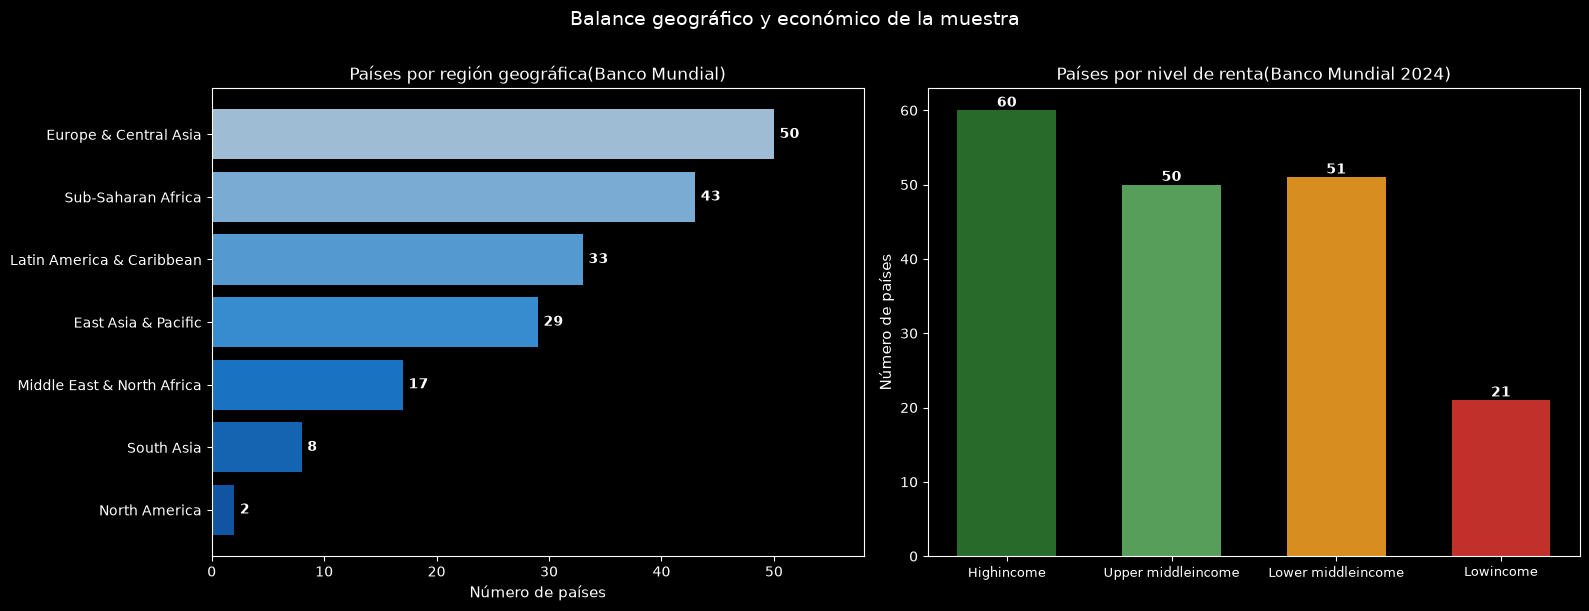

Total países en el dataset: 182

Región más representada: Europe & Central Asia (50 países)
Región menos representada: North America (2 países)

 Nota: Sub-Saharan Africa y Europe & Central Asia dominan la muestra.
   Esto se tendrá en cuenta al interpretar promedios globales.


In [20]:
# ── BALANCE GEOGRÁFICO ───────────────────────────────────────────────────
#
# Contamos cuántos países únicos hay en cada región del Banco Mundial.
# Usamos drop_duplicates() para contar países, no filas
# (cada país tiene 30 filas — una por año)

paises_por_region = (
    df_full[["geo", "region_wb", "income_group"]]
    .drop_duplicates()  # una fila por país
    .groupby("region_wb")["geo"]
    .count()  # contar países por región
    .sort_values(ascending=True)  # orden ascendente para barh
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel izquierdo: barras horizontales por región ───────────────────────────
colores = ["#1565C0", "#1976D2", "#1E88E5", "#42A5F5", "#64B5F6", "#90CAF9", "#BBDEFB"]
bars = axes[0].barh(
    paises_por_region.index, paises_por_region.values, color=colores, alpha=0.85
)

# Etiquetas de valor al final de cada barra
for bar, val in zip(bars, paises_por_region.values):
    axes[0].text(
        val + 0.5,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va="center",
        fontsize=10,
        fontweight="bold",
    )

axes[0].set_xlabel("Número de países", fontsize=11)
axes[0].set_title("Países por región geográfica(Banco Mundial)", fontsize=12)
axes[0].set_xlim(0, paises_por_region.max() + 8)

# ── Panel derecho: barras por nivel de renta ──────────────────────────────────
paises_por_renta = (
    df_full[["geo", "income_group"]]
    .drop_duplicates()
    .groupby("income_group")["geo"]
    .count()
    .reindex(
        ["High income", "Upper middle income", "Lower middle income", "Low income"]
    )
)

colores_renta = ["#2E7D32", "#66BB6A", "#FFA726", "#E53935"]
bars2 = axes[1].bar(
    range(len(paises_por_renta)),
    paises_por_renta.values,
    color=colores_renta,
    alpha=0.85,
    width=0.6,
)

for bar, val in zip(bars2, paises_por_renta.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.5,
        str(val),
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

axes[1].set_xticks(range(len(paises_por_renta)))
axes[1].set_xticklabels(
    ["Highincome", "Upper middleincome", "Lower middleincome", "Lowincome"], fontsize=9
)
axes[1].set_ylabel("Número de países", fontsize=11)
axes[1].set_title("Países por nivel de renta(Banco Mundial 2024)", fontsize=12)

plt.suptitle("Balance geográfico y económico de la muestra", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figures/balance_geografico.png", dpi=150, bbox_inches="tight")
plt.show()

# Resumen numérico
total = df_full["geo"].nunique()
print(f"Total países en el dataset: {total}")
print(
    f"\nRegión más representada: {paises_por_region.idxmax()} ({paises_por_region.max()} países)"
)
print(
    f"Región menos representada: {paises_por_region.idxmin()} ({paises_por_region.min()} países)"
)
print(f"\n Nota: Sub-Saharan Africa y Europe & Central Asia dominan la muestra.")
print(f"   Esto se tendrá en cuenta al interpretar promedios globales.")

### 2 - ¿Cómo de profunda es la brecha de datos del desempleo?

**Objetivo:** justificar visualmente la decisión de separar `df_full`
y `df_unemp`. El desempleo es una variable "cara" de obtener —
solo existe para un subconjunto de países.

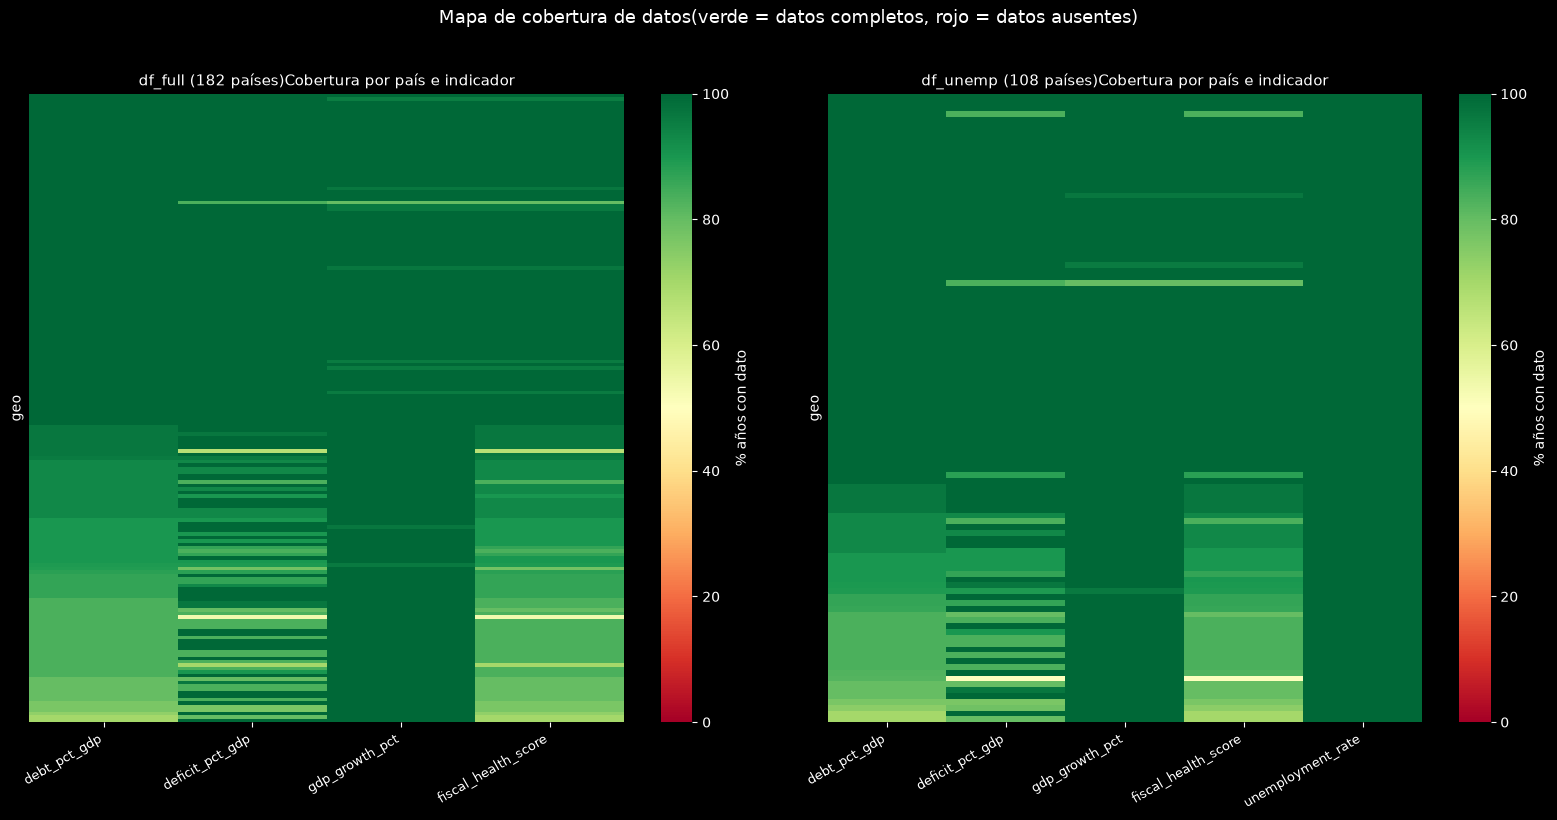

Cobertura media por indicador (% de filas con dato):
   debt_pct_gdp              → 94.0%
   deficit_pct_gdp           → 96.2%
   gdp_growth_pct            → 99.7%
   fiscal_health_score       → 93.1%
   unemployment_rate         → 100.0% (solo en df_unemp)


In [21]:
# ── BRECHA DE DATOS - HEATMAP DE NULOS ───────────────────────────────────
#
# Comparamos la cobertura de cada indicador en df_full vs df_unemp.
# Un heatmap de nulos muestra visualmente dónde faltan datos.

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, (nombre, df_viz) in zip(
    axes, [("df_full (182 países)", df_full), ("df_unemp (108 países)", df_unemp)]
):
    # Pivotamos: países en filas, indicadores en columnas
    # Calculamos % de NaN por país y columna
    cols_numericas = [
        "debt_pct_gdp",
        "deficit_pct_gdp",
        "gdp_growth_pct",
        "fiscal_health_score",
    ]
    if "unemployment_rate" in df_viz.columns:
        cols_numericas.append("unemployment_rate")

    # Cobertura por país (% de años con dato)
    cobertura = df_viz.groupby("geo")[cols_numericas].apply(
        lambda x: x.notna().mean() * 100
    )

    # Ordenamos por cobertura media de deuda
    cobertura = cobertura.sort_values("debt_pct_gdp", ascending=False)

    sns.heatmap(
        cobertura,
        ax=ax,
        cmap="RdYlGn",  # rojo = pocos datos, verde = muchos datos
        vmin=0,
        vmax=100,
        cbar_kws={"label": "% años con dato"},
        yticklabels=False,  # demasiados países para mostrar todos
        linewidths=0,
    )
    ax.set_title(f"{nombre}Cobertura por país e indicador", fontsize=11)
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)

plt.suptitle(
    "Mapa de cobertura de datos(verde = datos completos, rojo = datos ausentes)",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.savefig("figures/cobertura_datos.png", dpi=150, bbox_inches="tight")
plt.show()

# Resumen numérico de cobertura
print("Cobertura media por indicador (% de filas con dato):")
for col in ["debt_pct_gdp", "deficit_pct_gdp", "gdp_growth_pct", "fiscal_health_score"]:
    pct = df_full[col].notna().mean() * 100
    print(f"   {col:25} → {pct:.1f}%")

if "unemployment_rate" in df_unemp.columns:
    pct_u = df_unemp["unemployment_rate"].notna().mean() * 100
    print(f"   {'unemployment_rate':25} → {pct_u:.1f}% (solo en df_unemp)")

### 3 - ¿Es el periodo 1995–2024 consistente para todos los niveles de renta?

**Objetivo:** demostrar que el filtro de cobertura ≥70% funcionó.
Las líneas deberían ser estables - si hubiera caídas bruscas en
algún año significaría que ese año no es comparable con los demás.

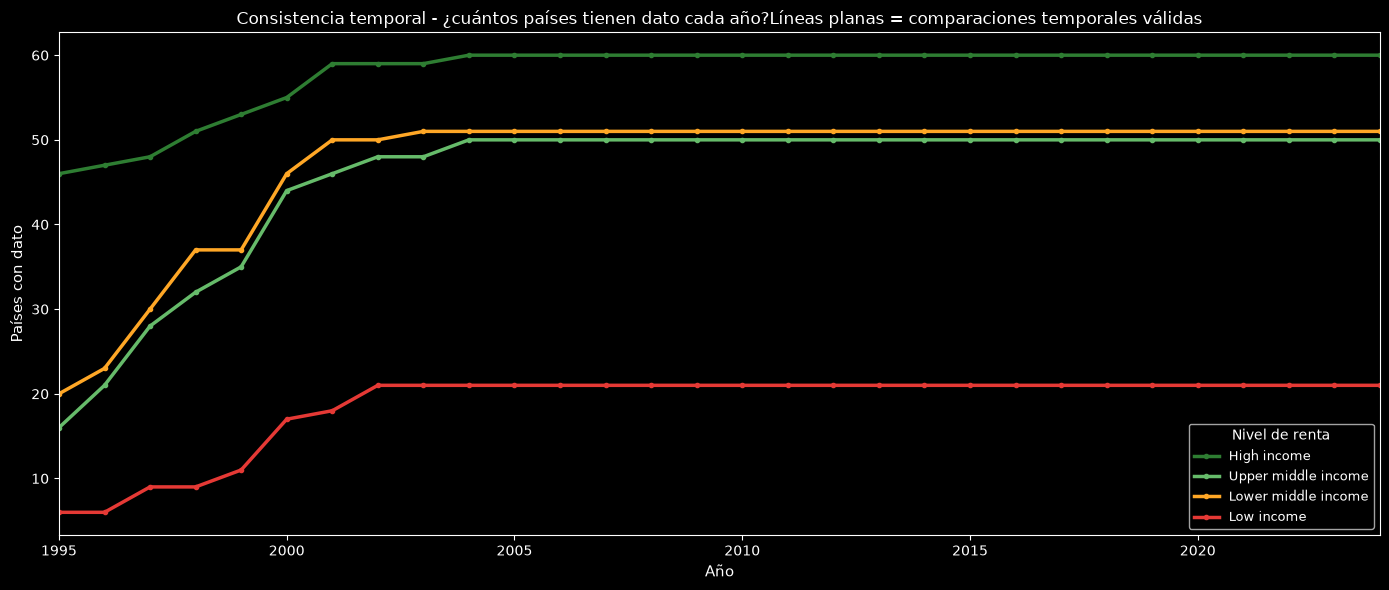

Estabilidad de la cobertura (desviación estándar del nº de países por año):
   High income               → media 58 países/año | std 4.3
   Upper middle income       → media 46 países/año | std 9.3
   Lower middle income       → media 47 países/año | std 8.6
   Low income                → media 19 países/año | std 4.9

→ Std cercano a 0 indica cobertura muy estable


In [22]:
# ── CONSISTENCIA TEMPORAL POR NIVEL DE RENTA ────────────────────────────
#
# Contamos cuántos países tienen dato en cada año, separados por income_group.
# Si las líneas son planas → el filtro funcionó → comparaciones válidas.
# Si hay caídas → ese año tiene menos cobertura → hay que tenerlo en cuenta.

registros_por_año = (
    df_full[df_full["debt_pct_gdp"].notna()]  # solo filas con dato
    .groupby(["year", "income_group"])["geo"]
    .nunique()  # países únicos por año y grupo
    .reset_index()
    .rename(columns={"geo": "n_paises"})
)

fig, ax = plt.subplots(figsize=(14, 6))

colores_renta = {
    "High income": "#2E7D32",
    "Upper middle income": "#66BB6A",
    "Lower middle income": "#FFA726",
    "Low income": "#E53935",
}

for grupo, color in colores_renta.items():
    mask = registros_por_año["income_group"] == grupo
    if mask.sum() == 0:
        continue
    datos = registros_por_año[mask]
    ax.plot(
        datos["year"],
        datos["n_paises"],
        label=grupo,
        color=color,
        linewidth=2.5,
        marker="o",
        markersize=3,
    )

ax.set_xlabel("Año", fontsize=11)
ax.set_ylabel("Países con dato", fontsize=11)
ax.set_title(
    "Consistencia temporal - ¿cuántos países tienen dato cada año?"
    "Líneas planas = comparaciones temporales válidas",
    fontsize=12,
)
ax.legend(title="Nivel de renta", fontsize=9)
ax.set_xlim(1995, 2024)

plt.tight_layout()
plt.savefig("figures/consistencia_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

# Variabilidad por grupo
print("Estabilidad de la cobertura (desviación estándar del nº de países por año):")
for grupo in colores_renta.keys():
    mask = registros_por_año["income_group"] == grupo
    std = registros_por_año[mask]["n_paises"].std()
    media = registros_por_año[mask]["n_paises"].mean()
    print(f"   {grupo:25} → media {media:.0f} países/año | std {std:.1f}")
print("\n→ Std cercano a 0 indica cobertura muy estable")

### 4 - ¿Qué importancia tienen los outliers en la distribución global?

**Objetivo:** identificar visualmente los valores extremos que
documentamos en la sección 3.5. Esto justifica por qué en las
visualizaciones de la Parte II usaremos escalas acotadas o
logarítmicas para que un solo país no rompa el gráfico.

C:\Users\User\AppData\Local\Temp\ipykernel_27880\134045084.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_27880\134045084.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_27880\134045084.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_27880\134045084.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(


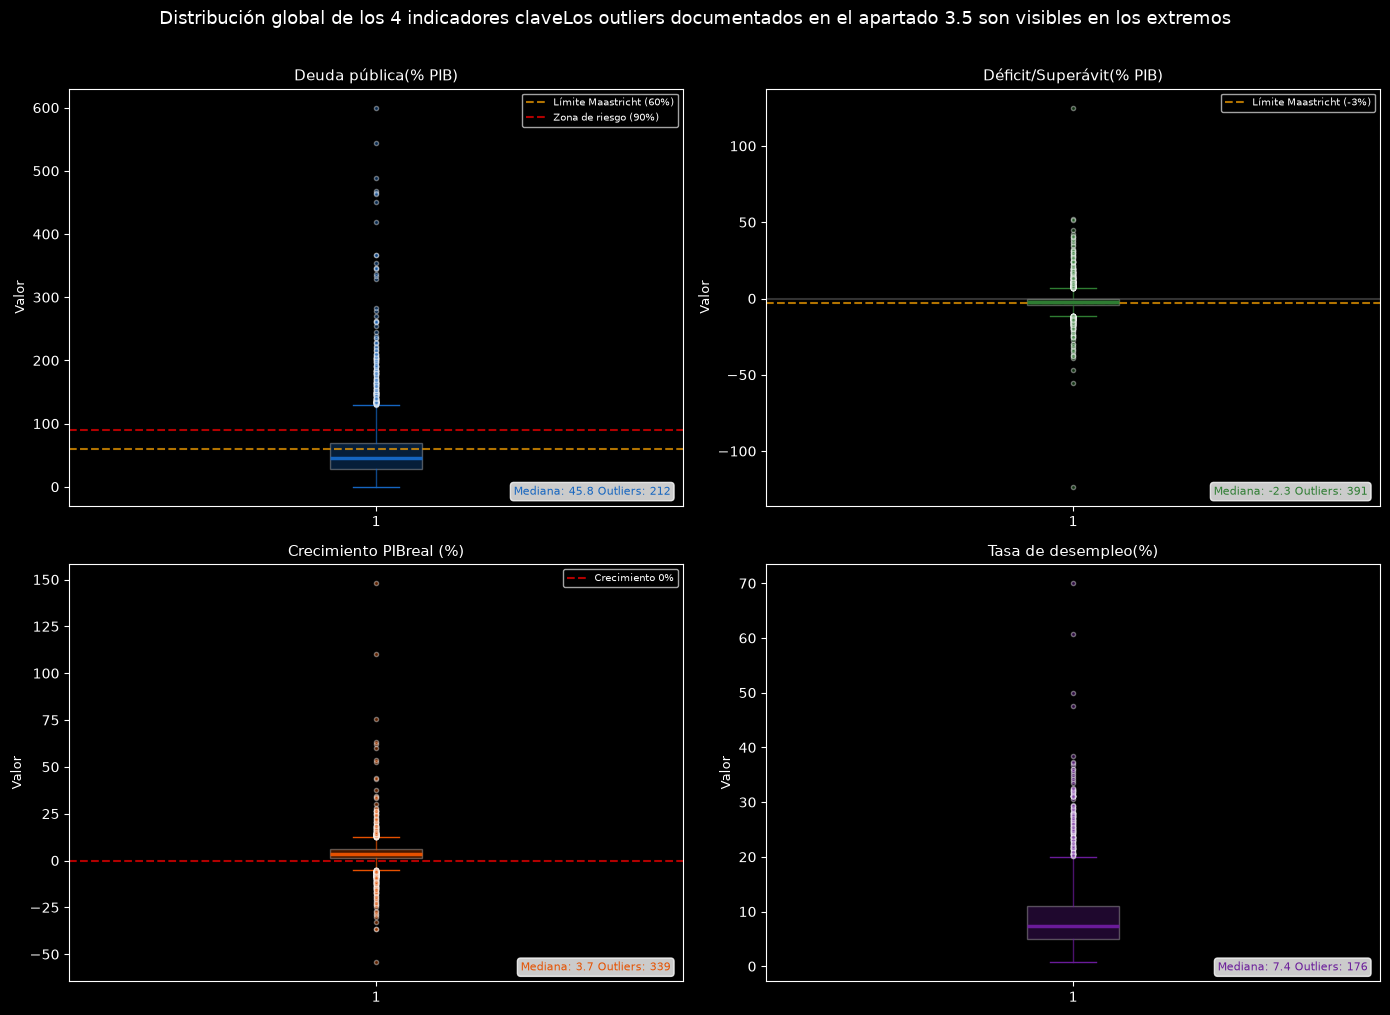

Resumen de outliers por indicador:
   debt_pct_gdp              →  212 outliers (4.2%)
   deficit_pct_gdp           →  391 outliers (7.5%)
   gdp_growth_pct            →  339 outliers (6.3%)
   unemployment_rate         →  176 outliers (5.6%)


In [23]:
# ── DISTRIBUCIÓN Y OUTLIERS - BOXPLOTS ───────────────────────────────────
#
# Los boxplots muestran la distribución de cada indicador y hacen
# visibles los outliers (puntos fuera de los bigotes).
#
# Estructura de un boxplot:
# - Caja: rango intercuartílico (Q1 a Q3, el 50% central de los datos)
# - Línea central: mediana
# - Bigotes: hasta 1.5 * IQR desde la caja
# - Puntos: outliers (valores fuera de los bigotes)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

indicadores = [
    ("debt_pct_gdp", "Deuda pública(% PIB)", "#1565C0", 150),
    ("deficit_pct_gdp", "Déficit/Superávit(% PIB)", "#2E7D32", None),
    ("gdp_growth_pct", "Crecimiento PIBreal (%)", "#E65100", None),
    ("unemployment_rate", "Tasa de desempleo(%)", "#6A1B9A", None),
]

for ax, (col, titulo, color, clip_val) in zip(axes, indicadores):
    # Usamos df_unemp para el desempleo, df_full para el resto
    df_viz = df_unemp if col == "unemployment_rate" else df_full
    datos = df_viz[col].dropna()

    # Boxplot con stripplot superpuesto para ver densidad
    bp = ax.boxplot(
        datos,
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.3),
        medianprops=dict(color=color, linewidth=2.5),
        whiskerprops=dict(color=color, alpha=0.7),
        capprops=dict(color=color),
        flierprops=dict(marker="o", markerfacecolor=color, markersize=3, alpha=0.4),
    )

    # Líneas de referencia según el indicador
    if col == "debt_pct_gdp":
        ax.axhline(
            60,
            color="orange",
            linestyle="--",
            alpha=0.7,
            label="Límite Maastricht (60%)",
        )
        ax.axhline(
            90, color="red", linestyle="--", alpha=0.7, label="Zona de riesgo (90%)"
        )
        ax.legend(fontsize=7)
    elif col == "deficit_pct_gdp":
        ax.axhline(
            -3,
            color="orange",
            linestyle="--",
            alpha=0.7,
            label="Límite Maastricht (-3%)",
        )
        ax.axhline(0, color="gray", linestyle="-", alpha=0.4)
        ax.legend(fontsize=7)
    elif col == "gdp_growth_pct":
        ax.axhline(0, color="red", linestyle="--", alpha=0.7, label="Crecimiento 0%")
        ax.legend(fontsize=7)

    # Estadísticas clave
    q1, med, q3 = datos.quantile([0.25, 0.5, 0.75])
    n_outliers = (
        (datos < datos.quantile(0.25) - 1.5 * (q3 - q1))
        | (datos > datos.quantile(0.75) + 1.5 * (q3 - q1))
    ).sum()

    ax.set_title(f"{titulo}", fontsize=11)
    ax.set_ylabel("Valor", fontsize=9)
    ax.text(
        0.98,
        0.02,
        f"Mediana: {med:.1f} Outliers: {n_outliers}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        color=color,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

plt.suptitle(
    "Distribución global de los 4 indicadores clave"
    "Los outliers documentados en el apartado 3.5 son visibles en los extremos",
    fontsize=13,
    y=1.01,
)
plt.tight_layout()
plt.savefig("figures/boxplots_outliers.png", dpi=150, bbox_inches="tight")
plt.show()

print("Resumen de outliers por indicador:")
for col, titulo, _, _ in indicadores:
    df_viz = df_unemp if col == "unemployment_rate" else df_full
    datos = df_viz[col].dropna()
    q1, q3 = datos.quantile(0.25), datos.quantile(0.75)
    iqr = q3 - q1
    n_out = ((datos < q1 - 1.5 * iqr) | (datos > q3 + 1.5 * iqr)).sum()
    pct = n_out / len(datos) * 100
    print(f"   {col:25} → {n_out:4} outliers ({pct:.1f}%)")

---
## 6. Diccionario de Variables

### 6.1 Dimensiones (variables de contexto / categóricas)

| Variable | Tipo | Valores posibles | Descripción |
|----------|------|-----------------|-------------|
| `geo` | Dimensión | Código ISO 3166-1 alpha-3 (ESP, DEU...) | Código oficial de país |
| `country_name` | Dimensión | Nombre completo en inglés | Nombre oficial según endpoint `/countries` del FMI |
| `year` | Dimensión temporal | 1995–2024 (entero) | Año de la observación |
| `region_wb` | Dimensión geográfica | Europe & Central Asia / Sub-Saharan Africa / Latin America & Caribbean / East Asia & Pacific / Middle East & North Africa / South Asia / North America | Clasificación regional del Banco Mundial (CLASS.xlsx 2024) |
| `income_group` | Dimensión ordinal | High income / Upper middle income / Lower middle income / Low income | Nivel de renta según GNI per cápita — Banco Mundial 2024 |
| `debt_category` | Dimensión ordinal derivada | Bajo control (<60%) / Moderada (60–90%) / Preocupante (90–120%) / Nivel Crítico (>120%) | Clasificación de deuda usando umbrales del Tratado de Maastricht |
| `fiscal_dynamics` | Dimensión categórica derivada | Saludable / En recuperación / En deterioro / Crítico | Perfil fiscal combinado: cruza el impulso fiscal (crecimiento + saldo) con el signo del crecimiento |
| `vulnerability_level` | Dimensión ordinal derivada | Sano / Vulnerabilidad Moderada / Vulnerabilidad Alta (Alerta) | Solo en `df_unemp`. Clasifica el `vulnerability_score` en tres niveles de alerta |

### 6.2 Hechos (variables métricas descargadas del FMI)

| Variable | Tipo | Unidad | Código FMI | Cobertura | Descripción |
|----------|------|--------|-----------|-----------|-------------|
| `debt_pct_gdp` | Hecho continuo | % del PIB | `GGXWDG_NGDP` | ~182 países | Deuda bruta del gobierno general. Incluye todos los pasivos del sector público consolidado |
| `deficit_pct_gdp` | Hecho continuo | % del PIB | `GGXCNL_NGDP` | ~182 países | Saldo fiscal anual. Positivo = superávit, negativo = déficit |
| `gdp_growth_pct` | Hecho continuo | % variación anual | `NGDP_RPCH` | ~182 países | Crecimiento del PIB real, descontada la inflación |
| `unemployment_rate` | Hecho continuo | % población activa | `LUR` | ~108 países | Tasa de desempleo. Solo disponible en `df_unemp` |

### 6.3 Métricas derivadas (construidas en este proyecto)

| Variable | Dataset | Fórmula | Interpretación |
|----------|---------|---------|---------------|
| `debt_category` | `df_full` | `pd.cut(debt, [0,60,90,120,∞])` | Clasifica el nivel de deuda en 4 categorías usando los umbrales de Maastricht (60%) y del FMI (90%, 120%) como referencia |
| `fiscal_dynamics` | `df_full` | `impulso_neto = crecimiento + déficit`; clasifica según signo de `impulso_neto` y de `crecimiento` | Saludable (impulso+, crecimiento+), En recuperación (impulso+, crecimiento-), En deterioro (impulso-, crecimiento+), Crítico (impulso-, crecimiento-) |
| `fiscal_health_score` | `df_full` | Media ponderada de 3 indicadores normalizados por umbrales fijos | Índice 0–100 de salud fiscal. Umbrales fijos (no Min-Max) para que los valores tengan significado económico absoluto, no relativo al grupo |
| `vulnerability_score` | `df_unemp` | Suma de 4 condiciones booleanas (0–4) | Número de factores de riesgo simultáneos: deuda >90%, déficit <-3%, crecimiento <1%, desempleo >10% |
| `vulnerability_level` | `df_unemp` | `pd.cut(vulnerability_score, [-1,0,2,4])` | Clasifica el score en Sano / Moderada / Alta para facilitar la interpretación |

### 6.4 Cobertura y limitaciones

| Indicador | Países | Años | Limitaciones conocidas |
|-----------|--------|------|----------------------|
| `debt_pct_gdp` | 182 | 1995–2024 | Metodologías nacionales heterogéneas. Liberia tiene valores >400% en 2000–2005 (contexto: guerra civil) |
| `deficit_pct_gdp` | 182 | 1995–2024 | Guinea Ecuatorial tiene -123% en 1995 (contexto: PIB muy pequeño antes del boom petrolero) |
| `gdp_growth_pct` | 182 | 1995–2024 | Alta cobertura y fiabilidad |
| `unemployment_rate` | 108 | 1995–2024 | Cobertura limitada — excluye gran parte de África y Asia. Usar solo `df_unemp` para análisis con este indicador |
| `fiscal_health_score` | 182 | 1995–2024 | Los NaN en los indicadores base se propagan al score. Filtrar con `dropna()` antes de rankings |
| `vulnerability_score` | 108 | 1995–2024 | Depende del desempleo — mismas limitaciones de cobertura |


---
## 7. De los datos a las preguntas

Con el dataset limpio, auditado y los CSV listos, toca formular las
preguntas concretas que se van a responder con las visualizaciones.

| # | Pregunta | Indicadores | Visualización propuesta |
|---|---------|-------------|------------------------|
| Q1 | ¿Quién tiene la deuda más controlada y cómo ha evolucionado? | `debt_pct_gdp`, `debt_category` | Mapa coroplético animado |
| Q2 | ¿Hay países que crecen sin endeudarse? ¿Cuál es su perfil? | `debt_pct_gdp`, `gdp_growth_pct`, `fiscal_dynamics` | Scatter interactivo con filtros |
| Q3 | ¿Quién está en zona de riesgo en 2024? | Los 4 indicadores + `fiscal_dynamics` | Matriz de riesgo interactiva |
| Q4 | ¿La austeridad funciona? Países que redujeron deuda — ¿a qué coste en desempleo? | `debt_pct_gdp`, `unemployment_rate` | Small multiples — series temporales paralelas |
| Q5 | ¿Quién gestiona mejor? Ranking por `fiscal_health_score` | `fiscal_health_score` | Bar chart race animado 1995–2024 |

### Hipótesis a contrastar

- **H1:** Los países de renta alta no necesariamente tienen mejor
  salud fiscal — algunos de los scores más altos pertenecen a
  economías emergentes con baja deuda y alto crecimiento.
- **H2:** La reducción de deuda se asocia con aumento del desempleo
  en economías mediterráneas, pero no en economías nórdicas — el
  modelo de ajuste importa tanto como el ajuste en sí.
- **H3:** El `vulnerability_score` aumentó globalmente a partir de
  2020, pero de forma asimétrica: los países de renta baja
  acumularon más factores de riesgo que los de renta alta.


## 8. El plan para el dashboard en Tableau

El dashboard tiene una sola pantalla con tres vistas conectadas:

| Vista | Contenido |
|-------|-----------|
| Q1 — Mapa (vista general) | Deuda % PIB animada 1995–2024 |
| Q2 — Scatter | Deuda vs Crecimiento |
| Q3 — Matriz de riesgo | Situación 2024 (`fiscal_dynamics` x `income_group`) |

Cuando el usuario hace clic en un país o región en el mapa (Q1), el
scatter (Q2) y la matriz (Q3) se filtran solos. Eso es *linking &
brushing* — en Tableau se consigue con Dashboard Actions, no
manualmente.

Como Q1, Q2 y Q3 van en el mismo dashboard conectado, un solo CSV
sirve para los tres — no hace falta exportar tres archivos
separados.

In [24]:
# ── CSV ÚNICO PARA EL DASHBOARD Q1 + Q2 + Q3 ─────────────────────────────────
#
# Un solo archivo para las tres hojas de Tableau.
# Solo incluimos las columnas que realmente se usan — menos columnas
# significa que Tableau carga más rápido y no genera campos fantasma.

cols_dashboard = [
    "geo",  # código ISO alpha-3 → Tableau lo reconoce como país
    "country_name",  # nombre legible → para tooltips
    "year",  # año → animación en Q1, eje en Q2
    "debt_pct_gdp",  # Q1 (color mapa) + Q2 (eje X) + Q3
    "gdp_growth_pct",  # Q2 (eje Y)
    "deficit_pct_gdp",  # Q3 (matriz)
    "debt_category",  # Q1 (filtro lateral)
    "fiscal_dynamics",  # Q2 (color puntos) + Q3 (eje matriz)
    "region_wb",  # Q1/Q2/Q3 (filtro lateral)
    "income_group",  # Q2/Q3 (filtro lateral + eje matriz)
    "fiscal_health_score",  # Q3 (tamaño o color alternativo)
]

df_dashboard = df_full[cols_dashboard].dropna(subset=["debt_pct_gdp"]).copy()

# year como entero limpio — si queda como float Tableau lo muestra "1995.0"
df_dashboard["year"] = df_dashboard["year"].astype(int)

# Verificación rápida antes de exportar
print(f"Shape: {df_dashboard.shape}")
print(f"Años: {df_dashboard['year'].min()} – {df_dashboard['year'].max()}")
print(f"Países: {df_dashboard['geo'].nunique()}")
print(f"\nNulos por columna:")
print(df_dashboard.isnull().sum().to_string())

df_dashboard.to_csv(
    "data/imf_dashboard_tableau.csv",
    index=False,
    decimal=",",  # fuerza punto decimal
    sep=";",  # coma como separador de columnas
)

# Verificación — abre el CSV y mira las primeras líneas
with open("data/imf_dashboard_tableau.csv", "r") as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i >= 4:
            break
print(f"\nExportado: data/imf_dashboard_tableau.csv")

Shape: (5079, 11)
Años: 1995 – 2024
Países: 182

Nulos por columna:
geo                     0
country_name            0
year                    0
debt_pct_gdp            0
gdp_growth_pct         14
deficit_pct_gdp        39
debt_category          52
fiscal_dynamics        48
region_wb               0
income_group            0
fiscal_health_score    48
geo;country_name;year;debt_pct_gdp;gdp_growth_pct;deficit_pct_gdp;debt_category;fiscal_dynamics;region_wb;income_group;fiscal_health_score
ABW;Aruba;1995;55,1;9,0;-0,8;Bajo control (<60%);Saludable;Latin America & Caribbean;High income;74,87
ABW;Aruba;1996;54,8;1,6;-2,3;Bajo control (<60%);En deterioro;Latin America & Caribbean;High income;50,27
ABW;Aruba;1997;51,1;7,3;-2,1;Bajo control (<60%);Saludable;Latin America & Caribbean;High income;70,53
ABW;Aruba;1998;41,0;1,3;0,1;Bajo control (<60%);Saludable;Latin America & Caribbean;High income;57,67

Exportado: data/imf_dashboard_tableau.csv


**Nota técnica:** para que Tableau interprete correctamente los
decimales al importar este CSV, hay que exportar con coma como
separador decimal y punto y coma como separador de columnas:
`df.to_csv("archivo.csv", index=False, decimal=",", sep=";")`.

### Q4 - ¿La austeridad funciona?

**Pregunta:** los países que consiguieron reducir su deuda, ¿a qué
coste en desempleo lo hicieron?

Se exporta un CSV con series temporales paralelas de deuda y
desempleo, restringido a los países que en algún momento superaron
el 60% de deuda — el grupo relevante para analizar el efecto de un
ajuste fiscal.

In [25]:
# CSV para Q4 — series temporales paralelas
# Usamos df_unemp porque necesitamos unemployment_rate
# Países que en algún momento tuvieron deuda >60% — los interesantes para austeridad

cols_q4 = [
    "geo",
    "country_name",
    "year",
    "debt_pct_gdp",
    "unemployment_rate",
    "deficit_pct_gdp",
    "gdp_growth_pct",
    "region_wb",
    "income_group",
    "fiscal_dynamics",
]

df_q4 = df_unemp[cols_q4].dropna(subset=["debt_pct_gdp", "unemployment_rate"]).copy()
df_q4["year"] = df_q4["year"].astype(int)

df_q4.to_csv("data/imf_q4_austeridad.csv", index=False, decimal=",", sep=";")

print(f"Shape: {df_q4.shape}")
print(f"Países: {df_q4['geo'].nunique()}")
print(f"Años: {df_q4['year'].min()} – {df_q4['year'].max()}")

Shape: (2971, 10)
Países: 108
Años: 1995 – 2024


### Q5 - Ranking de salud fiscal (bar chart race)

Es la visualización más vistosa y la que mejor demuestra la evolución
del ranking de salud fiscal entre 1995 y 2024. Flourish necesita el
CSV en formato "ancho" — países en filas, años en columnas — así que
se pivota el dataset antes de exportarlo.

In [26]:
# CSV para Q5 — Bar chart race en Flourish
# Necesitamos: países en columnas, años en filas
# Flourish espera ese formato para el bar chart race

df_q5 = df_full.pivot_table(
    index="year", columns="country_name", values="fiscal_health_score", aggfunc="mean"
).round(2)

# Transponemos — países en filas, años en columnas
df_q5_flourish = df_q5.T.reset_index()
df_q5_flourish.columns.name = None

# La primera columna ahora es country_name
df_q5_flourish = df_q5_flourish.rename(columns={"country_name": "country_name"})

df_q5_flourish.to_csv("data/imf_q5_flourish.csv", index=False, decimal=".", sep=",")

print(f"Shape: {df_q5_flourish.shape}")
print(df_q5_flourish.iloc[:3, :5])

Shape: (182, 31)
  country_name   1995   1996   1997   1998
0  Afghanistan    NaN    NaN    NaN    NaN
1      Albania    NaN    NaN  17.29  51.07
2      Algeria  50.69  60.73  53.09  53.69


In [27]:
# Añadir región como categoría para colorear por región
region_map = df_full[["country_name", "region_wb"]].drop_duplicates()
df_q5_flourish = df_q5_flourish.merge(region_map, on="country_name", how="left")

# Reordenar — country_name, region_wb, luego los años
cols_orden = ["country_name", "region_wb"] + [
    c for c in df_q5_flourish.columns if c not in ["country_name", "region_wb"]
]
df_q5_flourish = df_q5_flourish[cols_orden]

df_q5_flourish.to_csv("data/imf_q5_flourish.csv", index=False, decimal=".", sep=",")
print(df_q5_flourish.iloc[:3, :5])

  country_name                   region_wb   1995   1996   1997
0  Afghanistan                  South Asia    NaN    NaN    NaN
1      Albania       Europe & Central Asia    NaN    NaN  17.29
2      Algeria  Middle East & North Africa  50.69  60.73  53.09
